In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create a sample dataset
df = pd.read_csv('student_performance.csv')
df.head()

,Student_ID,Attendance,Internal_Marks,Assignment_Marks,Study_Hours,Previous_Performance,Final_Score,Performance
0,1,83,84,40,8,78,70.6,1
1,2,96,57,92,8,93,76.9,1
2,3,73,65,78,3,83,86.1,1
3,4,59,76,79,7,95,74.6,1
4,5,87,41,66,3,51,58.1,0


In [2]:
# Separate Features and Target
X = df.iloc[:, 1:-1]  # All columns except the last one
y = df['Performance']

In [3]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.30,random_state=42,)

In [4]:
# Train Decision Tree Classifier with different depths and evaluate performance
depths = [3, 4, 5]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append([
        depth,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=['Depth', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)

print(results_df)

   Depth  Accuracy  Precision  Recall  F1-Score
0      3       1.0        1.0     1.0       1.0
1      4       1.0        1.0     1.0       1.0
2      5       1.0        1.0     1.0       1.0


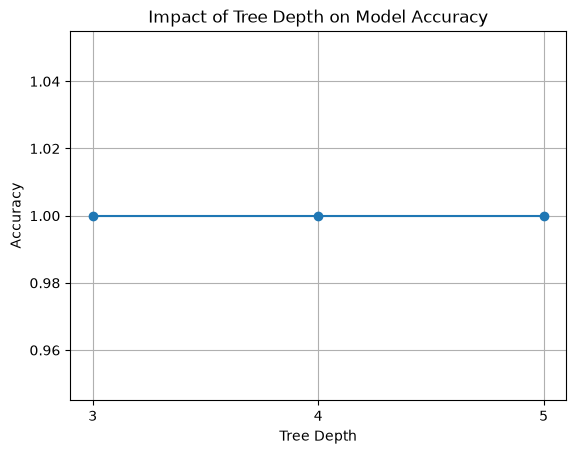

In [22]:
# Visualize the results
plt.plot(
    results_df['Depth'],
    results_df['Accuracy'],
    marker='o'
)

plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Impact of Tree Depth on Model Accuracy')
plt.xticks([3, 4, 5])
plt.grid(True)

plt.show()